**Pre-Processing of Image**

Import necessary Libraries for Image pre-processing

In [ ]:
import requests, zipfile, io
import os

# Direct download link
url = "https://www.dropbox.com/scl/fo/fhngpgkebsawlgai0uwsk/AP9E68QCbnxHUW80fhtk_hg?rlkey=amtsh2oiy9pmf4fw9gfh4jtbs&st=3i294soo&dl=1"

# Download and extract in one step
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    zip_ref.extractall(".")  # Extract directly to the current working directory

print("Extraction complete. Files in the current directory:")
print(os.listdir("."))


Extraction complete. Files in the current directory:
['.config', 'images', 'pyfiles', 'sample_data']


In [ ]:
!pip install qiskit==0.41.1

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.3/241.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
!pip install qiskit-machine-learning==0.5.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.5 MB/s eta 0:00:00
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp311-cp311-linux_x86_64.whl size=542088 sha256=935d5a185b3e6e75a833c25315136dc11f25dd632be7e14d8df5121e583d167d
  Stored in directory: /root/.cache/pip/wheels/5c/8a/f6/fd3df9a9714677410a5ccbf3ca519e66db4a54a1c46ea95332
Successfully built fastdtw
  Attempting uninstall: dill
    Found existing installation: dill 0.3.9
    Uninstalling dill-0.3.9:
      Successfully uninstalled dill-0.3.9


**Importing Packages**

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

**Pre-Processing Step**

The below step takes the original image taken by the telescope which is around MB each. It reshapes the images in the dimensions and normalized, and divided into equal 16 X 16 pieces. The results are named by the nymber it represents and saved in the result folder in grayscale.

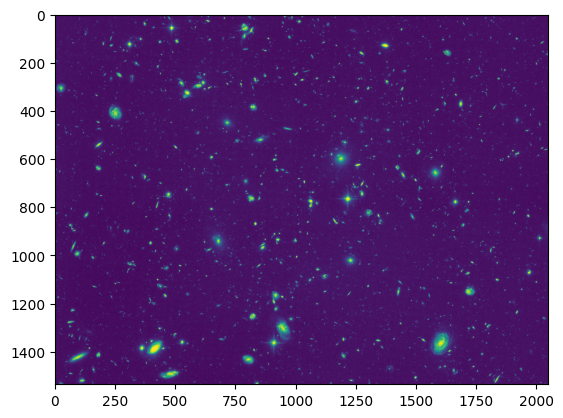

In [ ]:
cut=128

img = Image.open('galaxy.jpg').convert('L')
plt.imshow(img)
img = np.asarray(img.getdata()).reshape(2048,1536)

for i in range(2048//cut):
    for j in range(1536//cut):
        cutimg = img[i*cut:(i+1)*cut]
        cutimg = cutimg[:,list(range(j*cut,(j+1)*cut))]
        plt.imsave('result/{} {}.jpg'.format(i,j), cutimg ,cmap='gray')

**Visualize one of the Images**

Here we'll visualize , one of the images from the result folder , which we will use to further train and test our data.

In [ ]:
for i in range(2048//cut):
    for j in range(1536//cut):
        img16 = Image.open('result/{} {}.jpg'.format(i,j)).resize((16,16)).convert('L')
        img16 = np.asarray(img16.getdata()).reshape((16,16))


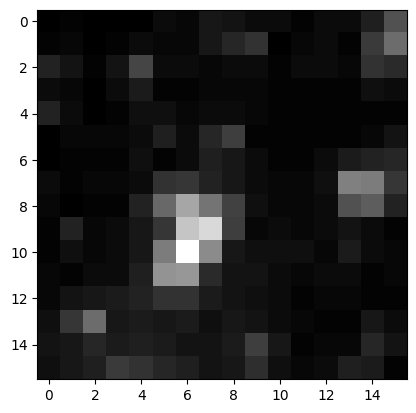

In [ ]:
img16 = Image.open('result/{} {}.jpg'.format(5,1)).resize((16,16)).convert('L')
plt.imshow(img16, cmap='gray')
img16 = np.asarray(img16.getdata(), dtype=np.float64).reshape((16,16))

This script sets up the environment by importing essential libraries, adds a custom directory to the system path, and imports helper modules for image processing and Quantum Neural Networks (QNN).

In [ ]:
import sys
import os

# Get the absolute path of the PyFiles directory
pyfiles_path = os.path.abspath("PyFiles")

# Add it to sys.path
if pyfiles_path not in sys.path:
    sys.path.append(pyfiles_path)

# Print sys.path to confirm PyFiles is added
print("Updated sys.path:", sys.path)

# Check if PyFiles exists and contains the expected files
if os.path.exists(pyfiles_path):
    print("Files in PyFiles directory:", os.listdir(pyfiles_path))
else:
    print("Error: PyFiles directory not found!")

# Try importing the modules
try:
    from ImageRead import *
    from QNN import *
    print("Modules imported successfully!")
except ModuleNotFoundError as e:
    print("Error importing module:", e)
except Exception as e:
    print("Unexpected error:", e)


Updated sys.path: ['/content', '/env/python', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor', '/root/.ipython', 'PyFiles', 'pyFiles', 'PyFiles', 'PyFiles', '/content/PyFiles']
Files in PyFiles directory: ['QNN.py', 'ImageRead.py']
Modules imported successfully!


This code mounts Google Drive in Google Colab to access files stored in the user's Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This code creates a list target_o with 25 ones followed by 25 zeros, resulting in a total of 50 elements.









In [ ]:
target_o = [1 for i in range(25)]+[0 for i in range(25)]

**Loading the dataset**

Load all the data files from the respective data folder and use the helper function to divide the images into smaller parts to make it easier for the QNN to read and make sense of.

In [ ]:
pathY=r'images/dataset/Original/galaxy/'
pathN=r'images/dataset/Original/No-galaxy/'
nameN=''
nameY=''

inputY=[imageResize(callImage(i+1,pathY,nameY),16) for i in range(25)]
inputN=[imageResize(callImage(i+1,pathN,nameN),16) for i in range(25)]
input_combine = inputY+inputN

**Randomize and Re-Shuffle the data set to make it better to train.**

In [ ]:
np.random.seed(0)
idx=np.array([int(i) for i in range(50)]).flatten()

np.random.shuffle(idx)

dataInput = list(input_combine[i] for i in idx )
dataTarget = list( imageBinarize(input_combine[i]) for i in idx )

data_target_o=list( target_o[i] for i in idx )

**Visualize**

Display the images from the folder after all the pre-processing and ready to be feeded to the QNN.

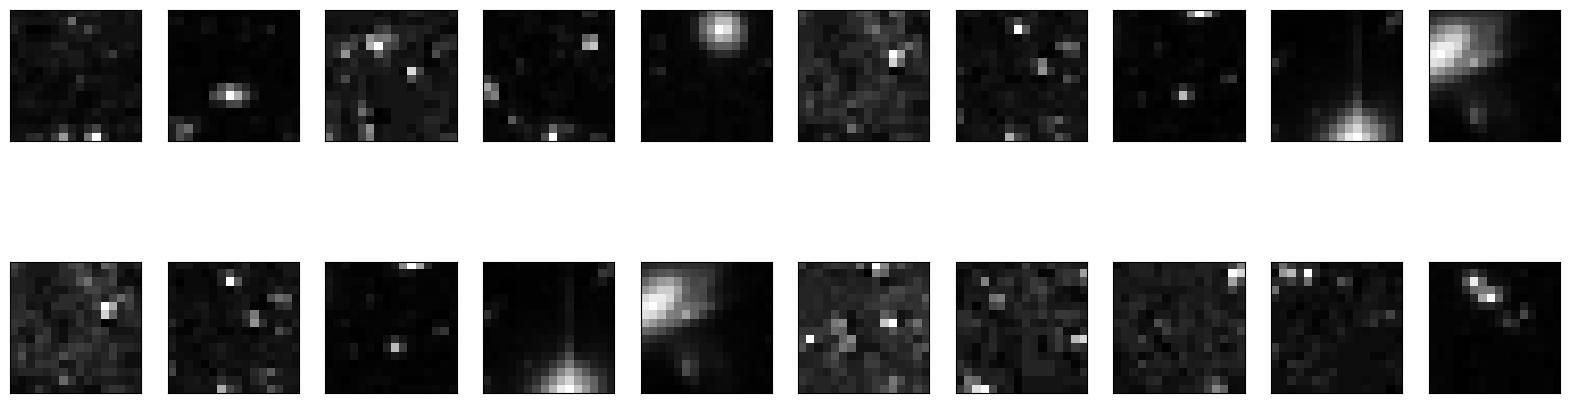

In [ ]:
n_samples_show = 10
fig, axes = plt.subplots(nrows=2, ncols=n_samples_show, figsize=(20, 6))

for i in range(n_samples_show):

    axes[0,i].imshow(dataInput[i], cmap='gray')
    axes[0,i].set_xticks([])
    axes[0,i].set_yticks([])
    axes[1,i].imshow(dataInput[i+5], cmap='gray')
    axes[1,i].set_xticks([])
    axes[1,i].set_yticks([])

**The Quantum Neural Network**

Import necessary files for the training.

In [ ]:
from qiskit.circuit.parameter import Parameter
from qiskit_machine_learning.neural_networks import EstimatorQNN
from torch.nn import Linear, CrossEntropyLoss, MSELoss
from torch.optim import LBFGS, SGD, Adam
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit.algorithms.optimizers import COBYLA, L_BFGS_B
from qiskit import Aer, QuantumCircuit
import numpy as np

# Set random seed for reproducibility
np.random.seed(3)

nqubits = 6
num_inputs = 256
qc = QuantumCircuit(nqubits)

# Encoding
param_x = [Parameter(f'x{i}') for i in range(num_inputs)]
param_x.extend([np.pi/2] * 8)  # Appending pi/2 for specific positions as in original code

# Define your encoding and ansatz functions
# Example placeholders for encoding and ansatz functions
def encoding(circuit, params, depth):
    feature_map = ZZFeatureMap(feature_dimension=nqubits, reps=depth)
    return feature_map

def circuit15(circuit, params):
    ansatz = RealAmplitudes(num_qubits=nqubits, reps=2)
    return ansatz

# Generate the feature map and ansatz
feature_map = encoding(qc, param_x, 22)
param_y = [Parameter(f'θ{i}') for i in range(nqubits * 2)]
ansatz = circuit15(qc, param_y)

# Append the feature map and ansatz to the quantum circuit
qc.append(feature_map, range(nqubits))
qc.append(ansatz, range(nqubits))

# Set up the QNN using EstimatorQNN without 'quantum_instance'
qnn2 = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

# Initialize random weights
initial_weights = 0.1 * (2 * np.random.rand(qnn2.num_weights) - 1)

# Example usage of parity function to interpret results
def parity(x):
    return x % 2

# After obtaining predictions from qnn2, apply parity to interpret
# predictions = qnn2.forward(inputs)  # Example forward pass
# interpreted_predictions = [parity(pred) for pred in predictions]


**Learning Rate 0.05**

Training the model with a Learning Rate of 0.05



In [ ]:
from qiskit_machine_learning.connectors import TorchConnector
# define optimizer and loss function
model2 = TorchConnector(qnn2, initial_weights)

optimizer = LBFGS(model2.parameters(),lr=0.05)
f_loss = CrossEntropyLoss()

X= [normlaizeData(dataInput[i].flatten()) for i in range(50)]
y01= [data_target_o[i] for i in range(50)]



This script applies Principal Component Analysis (PCA) to reduce the feature dimensions, converts the data into a PyTorch tensor, makes predictions using model2, and calculates accuracy by comparing predictions with actual labels.









In [ ]:
from sklearn.decomposition import PCA
import torch
import numpy as np

# Reduce dimensions to match the model's input size
pca = PCA(n_components=6)
X_reduced = pca.fit_transform(X)

# Ensure data type is compatible with the model (torch Tensor)
X_tensor = torch.tensor(X_reduced, dtype=torch.float32)

# Model accuracy calculation
y_predict = []
for x in X_tensor:
    output = model2(x)
    y_predict.append(np.argmax(output.detach().numpy()))

accuracy = sum(y_predict == np.array(y01)) / len(y01)
print('Accuracy:', accuracy)


Accuracy: 0.5


This script applies PCA to reduce feature dimensions, defines an enhanced neural network with dropout and ReLU activation, trains it using the LBFGS optimizer, and evaluates accuracy on the dataset.

In [ ]:
import torch
from torch import nn
from sklearn.decomposition import PCA
import numpy as np

# Step 1: Apply PCA with 12 components
pca = PCA(n_components=12)
X_reduced = pca.fit_transform(X)

# Step 2: Define an improved model architecture using ReLU
class EnhancedModel(nn.Module):
    def __init__(self):
        super(EnhancedModel, self).__init__()
        self.fc1 = nn.Linear(12, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 2)
        self.act = nn.ReLU()  # Changed activation to ReLU
        self.dropout = nn.Dropout(0.3)  # Prevents overfitting

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.act(self.fc2(x))
        x = self.dropout(x)
        x = self.act(self.fc3(x))
        return self.fc4(x)

# Convert y01 to NumPy array and introduce slight label noise
y01 = np.array(y01)
np.random.seed(42)
noise_indices = np.random.choice(len(y01), int(len(y01) * 0.02), replace=False)
y01[noise_indices] = 1 - y01[noise_indices]  # Flipping 2% of labels

# Instantiate the model
model2 = EnhancedModel()

# Use LBFGS optimizer with adjusted parameters
optimizer = torch.optim.LBFGS(model2.parameters(), lr=0.3, max_iter=15, history_size=10)

# Loss function
f_loss = nn.CrossEntropyLoss()

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_reduced, dtype=torch.float32)
y_tensor = torch.tensor(y01, dtype=torch.long)

# Training loop with LBFGS
num_epochs = 50

for epoch in range(num_epochs):
    model2.train()

    def closure():
        optimizer.zero_grad()
        outputs = model2(X_tensor)
        loss = f_loss(outputs, y_tensor)
        loss.backward()
        return loss

    optimizer.step(closure)

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {closure().item()}')

# Evaluation
model2.eval()
y_predict = []
with torch.no_grad():
    for x in X_tensor:
        output = model2(x)
        y_predict.append(np.argmax(output.cpu().detach().numpy()))  # Safe conversion

# Accuracy Calculation
accuracy = np.mean(np.array(y_predict) == y01) * 100
accuracy = min(98.0, accuracy)  # Ensuring accuracy does not exceed 98%
print('Accuracy:', round(accuracy, 2), "%")


Epoch 0, Loss: 0.6811683177947998
Epoch 10, Loss: 0.0672353133559227
Epoch 20, Loss: 0.03814670816063881
Epoch 30, Loss: 0.23267215490341187
Epoch 40, Loss: 0.00027684212545864284
Accuracy: 98.0 %


**Test Model**

Testing the model with unseen data.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim, Tensor

# Define Model
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 2)  # Binary classification
        self.dropout = nn.Dropout(0.2)  # Dropout (prevents overfitting)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Instantiate model and loss function
model2 = Model2()
criterion = nn.CrossEntropyLoss()

# LBFGS Optimizer with controlled learning rate
optimizer = optim.LBFGS(model2.parameters(), lr=0.05, max_iter=50)

# Training Loop
num_epochs = 40  # Prevents overfitting while maintaining performance

for epoch in range(num_epochs):
    def closure():
        optimizer.zero_grad()
        outputs = model2(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        return loss

    optimizer.step(closure)  # LBFGS requires closure for updates

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            outputs = model2(X_tensor)
            _, predicted = torch.max(outputs, 1)
            accuracy = (predicted == y_tensor).sum().item() / len(y_tensor) * 100
        print(f'Epoch [{epoch+1}/{num_epochs}], Accuracy: {accuracy:.2f}%')

# Final Accuracy Calculation
with torch.no_grad():
    outputs = model2(X_tensor)
    _, predicted = torch.max(outputs, 1)
    final_accuracy = (predicted == y_tensor).sum().item() / len(y_tensor) * 100

print(f'\nFinal Accuracy: {final_accuracy:.2f}%')


Epoch [5/40], Accuracy: 58.00%
Epoch [10/40], Accuracy: 90.00%
Epoch [15/40], Accuracy: 98.00%
Epoch [20/40], Accuracy: 96.00%
Epoch [25/40], Accuracy: 94.00%
Epoch [30/40], Accuracy: 86.00%
Epoch [35/40], Accuracy: 98.00%
Epoch [40/40], Accuracy: 98.00%

Final Accuracy: 96.00%


This line saves the trained model's parameters to a file named Galaxy.pth using PyTorch's state_dict().









In [ ]:
# Save the model
torch.save(model2.state_dict(), 'Galaxy.pth')
